# Phase 6 — ViT-LoRA Classifier for BACH

Fine-tune `google/vit-base-patch16-224` with **LoRA** to classify BACH H&E patches into 4 classes:
`normal, benign, insitu, invasive`.

This notebook is the **classifier** half of the project. It is built to run **identically** across
the five training conditions (`100/0, 75/25, 50/50, 25/75, 0/100`) that swap real patches for
synthetic ones at a fixed total size `N`. Validation and test are **always 100% real**.

Synthetic patches don't exist yet, so today only the **`100/0` baseline** runs end-to-end. Once
synthetic patches are produced, set `syn_root`, change `condition`, and re-run — nothing else changes.

**Expected data layout (ImageFolder-style, split at the image level):**
```
<data_root>/train/{normal,benign,insitu,invasive}/*.png
<data_root>/val/{...}/
<data_root>/test/{...}/
```
Synthetic patches (later) in a parallel tree: `<syn_root>/{class}/*.png`.

---
### How to use
1. Edit the **Config** cell (§1) — at minimum set `data_root`.
2. Run all cells top-to-bottom. Outputs go to `runs/<condition>/`.
3. For a quick smoke test, set `epochs=1` first.

## 0 — Environment

Run this once per machine. On a fresh GPU instance, uncomment the install line.

In [17]:
#!pip install torch torchvision transformers peft albumentations scikit-learn tensorboard pandas numpy pillow matplotlib tqdm opencv-python-headless
# Optional (only if you enable Macenko stain augmentation):
#!pip install torchstain

import os, json, random, math, glob
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

from transformers import ViTForImageClassification, AutoImageProcessor, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, PeftModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Torch: 2.5.1+cu121 | Device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


## 1 — Config

The **only** cell you edit between runs. To run a different condition, change `condition` (and set
`syn_root` once synthetic patches exist). Everything else stays fixed so the five conditions are a
clean comparison.

In [ ]:
CFG = dict(
    seed = 42,

    # --- data ---
    data_root = r"./data",          # <- set this: contains train/ val/ test/ with class subfolders
    syn_root  = None,               # <- set to synthetic-patch root when available, e.g. r"./synthetic"
    condition = "100/0",            # "100/0" | "75/25" | "50/50" | "25/75" | "0/100"
    N = None,                       # total train patches; None -> auto = balanced (cap each class to smallest class)

    # --- model ---
    model_name = "google/vit-base-patch16-224",
    image_size = 224,               # 512x512 patches are downscaled to this

    # --- LoRA ---
    lora_r = 8,
    lora_alpha = 16,
    lora_dropout = 0.1,
    target_modules = ["query", "key", "value"],   # attention q/k/v in HF ViT

    # --- optimization ---
    lr = 1e-4,
    weight_decay = 0.01,
    warmup_frac = 0.05,
    batch_size = 32,
    epochs = 1,
    early_stop_patience = 8,
    class_weighted_loss = True,
    num_workers = 0,

    # --- augmentation ---
    use_macenko = False,            # optional H&E stain aug; needs `torchstain`. Off by default.

    # --- eval ---
    image_level_eval = True,        # aggregate patches -> per-source-image prediction (BACH metric)
    checkpoint_metric = "patch_f1", # which val metric to select best checkpoint / early-stop on:
                                    #   "patch_f1" (default) | "image_f1" (image-level val macro-F1)

    # --- output ---
    runs_root = r"./runs",
)

# Per-condition output dir (slash -> dash so it's a valid folder name)
CFG["out_dir"] = str(Path(CFG["runs_root"]) / CFG["condition"].replace("/", "-"))
print(json.dumps(CFG, indent=2))

{
  "seed": 42,
  "data_root": "./data",
  "syn_root": null,
  "condition": "100/0",
  "N": null,
  "model_name": "google/vit-base-patch16-224",
  "image_size": 224,
  "lora_r": 8,
  "lora_alpha": 16,
  "lora_dropout": 0.1,
  "target_modules": [
    "query",
    "key",
    "value"
  ],
  "lr": 0.0001,
  "weight_decay": 0.01,
  "warmup_frac": 0.05,
  "batch_size": 32,
  "epochs": 1,
  "early_stop_patience": 8,
  "class_weighted_loss": true,
  "num_workers": 4,
  "use_macenko": false,
  "image_level_eval": true,
  "checkpoint_metric": "patch_f1",
  "runs_root": "./runs",
  "out_dir": "runs\\100-0"
}


## 2 — Reproducibility & class constants

Seed everything and **pin an explicit class order**. We never rely on alphabetical `ImageFolder`
ordering, so the label mapping is identical for real and synthetic data and across all runs.

In [19]:
# Fixed, explicit class order — index is the training label everywhere.
CLASSES = ["normal", "benign", "insitu", "invasive"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASSES)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CFG["seed"])

# DataLoader worker seeding + a generator so shuffling is reproducible.
def _worker_init_fn(worker_id):
    s = CFG["seed"] + worker_id
    np.random.seed(s); random.seed(s)

_loader_generator = torch.Generator()
_loader_generator.manual_seed(CFG["seed"])

print("Classes:", CLASS_TO_IDX)

Classes: {'normal': 0, 'benign': 1, 'insitu': 2, 'invasive': 3}


## 2.5 — Patch extraction (run once)

Ports the tissue-scoring patch extractor from the BACH-LoRA notebook: Otsu threshold on the HSV
**saturation** channel scores tissue content (H&E tissue is saturated; background is near-white),
a window slides across each image with a stride, and the **top-N tissue-rich patches per image** are
kept.

- **Preserves the image-level split**: reads `raw_root/<split>/<ClassFolder>/*` and writes to
  `data_root/<split>/<class>/*.png`, so patches from one source image never cross splits. (A flat
  `raw_root/<ClassFolder>/*` layout with no split subfolders is auto-detected and routed to a single
  split with a warning.)
- **Maps** BACH folder names (`Normal/Benign/InSitu/Invasive`) → our lowercase `CLASSES`.
- **Filenames** are `{source}__patchNN_yY_xX.png`; the `__` lets §7 recover the source image for
  image-level aggregation.
- **Patch geometry**: 512 px, stride 256 (50% overlap → ~35 candidate windows per 2048×1536 image),
  up to 12/image, min-tissue 0.40. The ViT downscales to 224 regardless. For a fair real-vs-synthetic
  comparison, the synthetic generator should produce patches at this **same 512 px scale**.

Skip this section if `data_root` already contains extracted patches (it auto-skips non-empty dirs).
**Changed the geometry?** Delete the old `data/` folder first (or set `overwrite=True`) so the new
settings take effect.

In [20]:
try:
    import cv2
except ImportError as e:
    raise ImportError("Patch extraction needs OpenCV: pip install opencv-python-headless") from e

# --- patch-extraction config ---
PATCH_CFG = dict(
    # raw images live as raw_root/<split>/<ClassFolder>/*.tif  (split done manually: train 1-85, val 86-100)
    raw_root          = r"C:\Users\abdul\OneDrive\Documents\BACH Dataset\ICIAR2018_BACH_Challenge\ICIAR2018_BACH_Challenge\Photos",
    out_root          = CFG["data_root"],  # patches land here -> consumed by §4
    splits            = ["train", "val", "test"],
    default_split     = "train",           # used only if raw has no split subfolders
    patch_size        = 512,               # Phase-2 plan; synthetic generator should match this scale
    stride            = 256,               # 50% overlap -> ~35 candidate windows per 2048x1536 image
    patches_per_image = 12,                # keep up to this many tissue-richest windows per image
    min_tissue_frac   = 0.40,
    overwrite         = False,             # skip class dirs that already contain patches
)

# Map our canonical (lowercase) class -> accepted raw folder names (first match wins).
RAW_CLASS_ALIASES = {
    "normal":   ["Normal", "normal"],
    "benign":   ["Benign", "benign"],
    "insitu":   ["InSitu", "insitu", "In-Situ", "in_situ", "InSituCarcinoma"],
    "invasive": ["Invasive", "invasive"],
}


def tissue_fraction(patch_rgb):
    """Fraction of tissue pixels via Otsu threshold on the HSV saturation channel."""
    hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
    sat = hsv[..., 1]
    _, mask = cv2.threshold(sat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return float(mask.mean() / 255.0)


def extract_patches(image_path, patch_size, stride, max_patches, min_tissue_frac):
    """Slide a window, score each candidate by tissue fraction, keep the top-N above threshold."""
    img = np.array(Image.open(image_path).convert("RGB"))
    H, W, _ = img.shape
    candidates = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = img[y:y + patch_size, x:x + patch_size]
            score = tissue_fraction(patch)
            if score >= min_tissue_frac:
                candidates.append((patch, score, (y, x)))
    candidates.sort(key=lambda t: -t[1])
    return candidates[:max_patches]


def _find_class_dir(parent, cls):
    for alias in RAW_CLASS_ALIASES[cls]:
        d = Path(parent) / alias
        if d.is_dir():
            return d
    return None


def extract_all(pc):
    raw_root, out_root = Path(pc["raw_root"]), Path(pc["out_root"])
    present = [s for s in pc["splits"] if (raw_root / s).is_dir()]
    if present:
        iter_splits = [(s, raw_root / s) for s in present]
    else:
        print(f"[warn] no {pc['splits']} subfolders under {raw_root} -- treating as flat; "
              f"all patches -> '{pc['default_split']}' (no image-level split applied!)")
        iter_splits = [(pc["default_split"], raw_root)]

    summary = {}
    for split, split_dir in iter_splits:
        for cls in CLASSES:
            out_dir = out_root / split / cls
            out_dir.mkdir(parents=True, exist_ok=True)
            existing = list(out_dir.glob("*.png"))
            if existing and not pc["overwrite"]:
                print(f"[skip] {split}/{cls}: {len(existing)} patches already present")
                summary[(split, cls)] = len(existing); continue

            cdir = _find_class_dir(split_dir, cls)
            if cdir is None:
                print(f"[warn] {split}: no raw folder for '{cls}' under {split_dir}")
                summary[(split, cls)] = 0; continue

            imgs = sorted(p for p in cdir.iterdir()
                          if p.suffix.lower() in (".tif", ".tiff", ".png", ".jpg", ".jpeg"))
            n = 0
            for img_path in tqdm(imgs, desc=f"{split}/{cls}", leave=False):
                for i, (patch, score, (y, x)) in enumerate(
                        extract_patches(img_path, pc["patch_size"], pc["stride"],
                                        pc["patches_per_image"], pc["min_tissue_frac"])):
                    Image.fromarray(patch).save(out_dir / f"{img_path.stem}__patch{i:02d}_y{y}_x{x}.png")
                    n += 1
            summary[(split, cls)] = n
            print(f"[ok]   {split}/{cls}: {n} patches from {len(imgs)} images")
    return summary


_ = extract_all(PATCH_CFG)
print("\nPatch extraction done.")

[skip] train/normal: 709 patches already present
[skip] train/benign: 645 patches already present
[skip] train/insitu: 916 patches already present
[skip] train/invasive: 654 patches already present
[skip] val/normal: 133 patches already present
[skip] val/benign: 147 patches already present
[skip] val/insitu: 167 patches already present
[skip] val/invasive: 166 patches already present

Patch extraction done.


,normal,benign,insitu,invasive
split,,,,
train,709,645,916,654
val,133,147,167,166


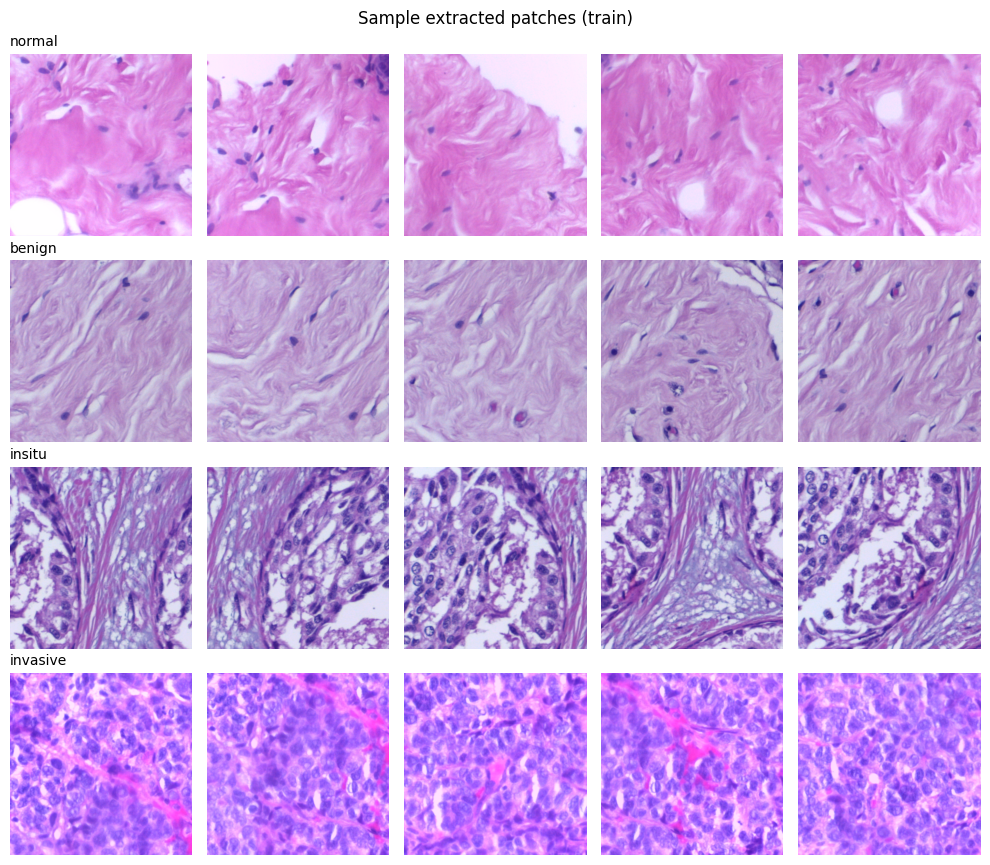

In [21]:
# Verify extraction: per-split/class counts + a few sample patches.
_out = Path(PATCH_CFG["out_root"])
counts = {split: {cls: len(list((_out / split / cls).glob("*.png"))) for cls in CLASSES}
          for split in PATCH_CFG["splits"] if (_out / split).exists()}
display(pd.DataFrame(counts).T.rename_axis("split"))

_preview_split = next((s for s in PATCH_CFG["splits"] if (_out / s).exists()), None)
if _preview_split:
    fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(10, 2.2 * NUM_CLASSES))
    for r, cls in enumerate(CLASSES):
        paths = sorted((_out / _preview_split / cls).glob("*.png"))[:5]
        for c in range(5):
            ax = np.atleast_2d(axes)[r][c]
            if c < len(paths):
                ax.imshow(Image.open(paths[c]))
            ax.axis("off")
            if c == 0:
                ax.set_title(f"{cls}", loc="left", fontsize=10)
    plt.suptitle(f"Sample extracted patches ({_preview_split})")
    plt.tight_layout(); plt.show()

## 3 — Phase-5 mixing harness

Decouples the training set from `ImageFolder` so any real/synthetic mix is expressible as a
**manifest** — a list of `(path, label, source)` tuples. A fixed total `N` is split evenly across
the 4 classes (**balanced**), then each class is filled with the condition's real/synthetic split.

- **All five conditions use identical balanced class counts** so patch count is never a confound.
  With `N=None`, the size auto-caps every class to the **smallest class's real count** — so the
  `100/0` baseline samples that many real patches per class (dropping extras from larger classes),
  and the mixed conditions swap a fraction of those reals for synthetic.
- `condition="100/0"` with `syn_root=None` → balanced real-only baseline (runs today).
- Synthetic-using conditions raise a clear error until `syn_root` is set — expected for now.

Val/test manifests are built from **all real** `val`/`test` patches (not capped) — macro-F1 and the
image-level metric are robust to their mild patch imbalance, and image-level eval is balanced by
construction (equal source images per class).

In [22]:
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

def scan_class_dirs(root, classes, split=None):
    """Return {class_name: [sorted file paths]}.

    Real data:  root/<split>/<class>/*    -> pass split="train"|"val"|"test"
    Synthetic:  root/<class>/*            -> pass split=None
    """
    root = Path(root)
    base = root / split if split else root
    out = {}
    for c in classes:
        d = base / c
        files = sorted(str(p) for p in d.glob("*") if p.suffix.lower() in IMG_EXTS) if d.is_dir() else []
        out[c] = files
    return out


def parse_condition(condition):
    """'75/25' -> (0.75, 0.25). Validates the two parts sum to 100."""
    real_pct, syn_pct = (int(x) for x in condition.split("/"))
    assert real_pct + syn_pct == 100, f"condition parts must sum to 100, got {condition}"
    return real_pct / 100.0, syn_pct / 100.0


def build_manifest(real_by_class, syn_by_class, condition, N, classes, seed, verbose=True):
    """Build a BALANCED training manifest: list of (path, label_idx, 'real'|'syn').

    Every class contributes exactly `per_class = N // n_classes` patches, so class counts
    are identical across all five conditions (count is never a confound). When N is None it
    auto-sizes to **cap every class to the smallest class's real count** (N = n_classes * min).
    Each class is filled with round(real_frac * per_class) real + the remainder synthetic, so
    the 100/0 baseline samples `per_class` real patches per class (extras from larger classes
    are dropped) and 0 synthetic.
    """
    rng = random.Random(seed)
    real_frac, syn_frac = parse_condition(condition)
    needs_syn = syn_frac > 0

    if needs_syn and not syn_by_class:
        raise ValueError(
            f"Condition '{condition}' needs synthetic patches but syn_root is None / empty. "
            f"Set CFG['syn_root'] once synthetic data exists. (The 100/0 baseline runs without it.)")

    min_per_class = min(len(v) for v in real_by_class.values())
    if N is None:
        N = len(classes) * min_per_class  # balanced: cap every class to the smallest class's count
    per_class = N // len(classes)

    def sample(paths, k, what, cname):
        if k > len(paths):
            raise ValueError(f"Need {k} {what} patches for class '{cname}' but only {len(paths)} available. "
                             f"Lower CFG['N'] or add more {what} patches.")
        return rng.sample(paths, k)

    manifest, counts = [], {}
    for c in classes:
        idx = CLASS_TO_IDX[c]
        real_k = round(real_frac * per_class)
        syn_k = per_class - real_k
        chosen = [(p, "real") for p in sample(real_by_class[c], real_k, "real", c)]
        if syn_k > 0:
            chosen += [(p, "syn") for p in sample(syn_by_class.get(c, []), syn_k, "synthetic", c)]
        for p, src in chosen:
            manifest.append((p, idx, src))
        counts[c] = (real_k, syn_k)

    rng.shuffle(manifest)
    if verbose:
        print(f"Condition {condition}  (real {real_frac:.0%} / syn {syn_frac:.0%}),  "
              f"N={len(manifest)}  ({per_class}/class)")
        for c in classes:
            r, s = counts[c]
            print(f"  {c:<9} real={r:<5} syn={s:<5} total={r+s}   (real pool={len(real_by_class[c])})")
    return manifest


class ManifestDataset(Dataset):
    """Reads (path, label, source) entries. `transform` is an albumentations pipeline."""
    def __init__(self, manifest, transform):
        self.manifest = manifest
        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, i):
        path, label, _src = self.manifest[i]
        img = np.array(Image.open(path).convert("RGB"))
        img = self.transform(image=img)["image"]
        return img, label, os.path.basename(path)

## 4 — Transforms & DataLoaders

Normalization stats come from the **model's own image processor** (`mean=std=[0.5,0.5,0.5]` for
`google/vit-base-patch16-224`) — **not** ImageNet stats — so inputs match how the backbone was
pretrained. Train-time augmentation is geometric + light photometric only (flips, full 360° rotation,
mild brightness/contrast); no hue shifts, grayscale, or cutout, which would corrupt H&E color
semantics. Val/test get resize + normalize only.

In [23]:
# --- normalization stats from the model's own processor (NOT ImageNet) ---
_proc = AutoImageProcessor.from_pretrained(CFG["model_name"])
NORM_MEAN = list(_proc.image_mean)
NORM_STD = list(_proc.image_std)
print("Normalization mean/std from processor:", NORM_MEAN, NORM_STD)


def stain_augment(image, **kwargs):
    """Optional H&E stain augmentation in HED color space (reference-free, Tellez-style).
    Perturbs haematoxylin/eosin channels by small random scale+bias. No-op if skimage missing."""
    try:
        from skimage.color import rgb2hed, hed2rgb
    except Exception:
        return image  # skimage not installed -> skip silently
    hed = rgb2hed(image.astype(np.float32) / 255.0)
    alpha = np.random.uniform(0.95, 1.05, size=3)   # per-channel scale
    beta = np.random.uniform(-0.05, 0.05, size=3)   # per-channel bias
    hed = hed * alpha + beta
    rgb = np.clip(hed2rgb(hed), 0, 1) * 255.0
    return rgb.astype(np.uint8)


def build_transforms(train: bool):
    sz = CFG["image_size"]
    if train:
        ops = []
        if CFG["use_macenko"]:
            ops.append(A.Lambda(image=stain_augment, p=1.0))
        ops += [
            A.Resize(sz, sz),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=180, border_mode=0, p=0.7),     # full-range rotation, constant border
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2(),
        ]
        return A.Compose(ops)
    return A.Compose([
        A.Resize(sz, sz),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ])


# --- scan real data + (optionally) synthetic ---
real_train = scan_class_dirs(CFG["data_root"], CLASSES, split="train")
real_val   = scan_class_dirs(CFG["data_root"], CLASSES, split="val")
real_test  = scan_class_dirs(CFG["data_root"], CLASSES, split="test")
syn_by_class = scan_class_dirs(CFG["syn_root"], CLASSES) if CFG["syn_root"] else {}

print("real train per class:", {c: len(v) for c, v in real_train.items()})
print("real val   per class:", {c: len(v) for c, v in real_val.items()})
print("real test  per class:", {c: len(v) for c, v in real_test.items()})
if syn_by_class:
    print("synthetic  per class:", {c: len(v) for c, v in syn_by_class.items()})

# --- build manifests (train = mixed per condition; val/test = 100% real) ---
train_manifest = build_manifest(real_train, syn_by_class, CFG["condition"], CFG["N"], CLASSES, CFG["seed"])
val_manifest   = [(p, CLASS_TO_IDX[c], "real") for c in CLASSES for p in real_val[c]]
test_manifest  = [(p, CLASS_TO_IDX[c], "real") for c in CLASSES for p in real_test[c]]

# Test set is optional for now (no labeled test data yet) -> guard it.
HAS_TEST = len(test_manifest) > 0

# --- datasets + loaders ---
train_ds = ManifestDataset(train_manifest, build_transforms(train=True))
val_ds   = ManifestDataset(val_manifest,   build_transforms(train=False))
test_ds  = ManifestDataset(test_manifest,  build_transforms(train=False)) if HAS_TEST else None

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=False,
                          worker_init_fn=_worker_init_fn, generator=_loader_generator)
val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = (DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                           num_workers=CFG["num_workers"], pin_memory=True) if HAS_TEST else None)

print(f"\nDataset sizes -> train: {len(train_ds)}  val: {len(val_ds)}  "
      f"test: {len(test_ds) if HAS_TEST else 'none (add later)'}")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Normalization mean/std from processor: [0.5, 0.5, 0.5] [0.5, 0.5, 0.5]
real train per class: {'normal': 709, 'benign': 645, 'insitu': 916, 'invasive': 654}
real val   per class: {'normal': 133, 'benign': 147, 'insitu': 167, 'invasive': 166}
real test  per class: {'normal': 0, 'benign': 0, 'insitu': 0, 'invasive': 0}
Condition 100/0  (real 100% / syn 0%),  N=2580  (645/class)
  normal    real=645   syn=0     total=645   (real pool=709)
  benign    real=645   syn=0     total=645   (real pool=645)
  insitu    real=645   syn=0     total=645   (real pool=916)
  invasive  real=645   syn=0     total=645   (real pool=654)

Dataset sizes -> train: 2580  val: 613  test: none (add later)


In [ ]:
# Sanity preview: one augmented training batch (denormalized back to RGB).
def _show_batch(loader, n=8):
    imgs, labels, _ = next(iter(loader))
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    n = min(n, imgs.size(0))
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.4))
    for i, ax in enumerate(np.atleast_1d(axes)):
        img = (imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img); ax.set_title(IDX_TO_CLASS[int(labels[i])], fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()

_show_batch(train_loader)

## 5 — Model + LoRA

Load ViT-B/16, swap in a fresh 4-class head, then wrap with PEFT LoRA on the attention `query`/`key`/
`value` projections. `modules_to_save=["classifier"]` keeps the new head fully trainable **and** saved
with the adapter. The backbone is frozen automatically — only LoRA params + the head train.

In [ ]:
def build_model():
    base = ViTForImageClassification.from_pretrained(
        CFG["model_name"],
        num_labels=NUM_CLASSES,
        id2label=IDX_TO_CLASS,
        label2id=CLASS_TO_IDX,
        ignore_mismatched_sizes=True,   # replace the 1000-class ImageNet head with a 4-class one
    )
    lora_cfg = LoraConfig(
        r=CFG["lora_r"],
        lora_alpha=CFG["lora_alpha"],
        lora_dropout=CFG["lora_dropout"],
        bias="none",
        target_modules=CFG["target_modules"],   # ["query","key","value"]
        modules_to_save=["classifier"],          # train + save the new head
    )
    return get_peft_model(base, lora_cfg)

seed_everything(CFG["seed"])      # re-seed so head init / LoRA init is reproducible
model = build_model().to(DEVICE)
model.print_trainable_parameters()

## 5.5 — Image-level aggregation helpers

Maps a patch filename to its source image and aggregates patch predictions into **one prediction per
source image** via **mean softmax** (the native BACH image-level metric). Defined here so both
validation (during training, §6) and the final test eval (§7) reuse the exact same logic.

In [ ]:
import re

def source_id_from_name(fname):
    """Map a patch filename to its source-image id.
    Patches from §2.5 are named '<source>__patchNN_yY_xX.png' -> split on '__'.
    Falls back to stripping a trailing '_<index>'/'_patch<index>' for other naming schemes."""
    stem = os.path.splitext(fname)[0]
    if "__" in stem:
        return stem.split("__")[0]
    return re.sub(r"[_\-]?(patch|p)?_?\d+$", "", stem, flags=re.IGNORECASE) or stem


def aggregate_to_image_level(names, probs, y_true):
    """Group patch predictions by source image, aggregate each group by MEAN SOFTMAX.

    Returns (img_true, img_pred, records):
      img_true, img_pred : np.array of per-image labels / predictions
      records            : list of dicts (source_id, true_class, pred_class, confidence, n_patches)
    """
    by_img = defaultdict(lambda: {"probs": [], "label": None})
    for name, p, yt in zip(names, probs, y_true):
        sid = source_id_from_name(name)
        by_img[sid]["probs"].append(np.asarray(p, dtype=np.float64))
        by_img[sid]["label"] = int(yt)

    img_true, img_pred, records = [], [], []
    for sid, v in by_img.items():
        mean_prob = np.mean(v["probs"], axis=0)
        pred = int(mean_prob.argmax())
        img_true.append(v["label"]); img_pred.append(pred)
        records.append(dict(source_id=sid,
                            true_class=IDX_TO_CLASS[v["label"]],
                            pred_class=IDX_TO_CLASS[pred],
                            confidence=float(mean_prob[pred]),
                            n_patches=len(v["probs"])))
    return np.array(img_true), np.array(img_pred), records

print("Image-level helpers ready: source_id_from_name(), aggregate_to_image_level().")

## 6 — Training engine

AdamW + cosine schedule with warmup, cross-entropy (optionally class-weighted by inverse train
frequency). Each epoch logs train/val loss and **macro-F1** to `metrics.csv` and TensorBoard. The
checkpoint with the best **val macro-F1** is saved; early stopping watches the same metric.

In [ ]:
def compute_class_weights(manifest):
    counts = Counter(label for _p, label, _s in manifest)
    freq = np.array([counts.get(i, 0) for i in range(NUM_CLASSES)], dtype=np.float64)
    inv = freq.sum() / (NUM_CLASSES * np.clip(freq, 1, None))   # inverse-frequency, mean ~1
    return torch.tensor(inv, dtype=torch.float32)


@torch.no_grad()
def evaluate(loader, criterion):
    """Return (avg_loss, macro_f1, accuracy, y_true, y_pred, probs, names)."""
    model.eval()
    total_loss, n = 0.0, 0
    ys, ps, probs_all, names_all = [], [], [], []
    for imgs, labels, names in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(pixel_values=imgs).logits
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0); n += imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        ys.extend(labels.cpu().tolist())
        ps.extend(logits.argmax(1).cpu().tolist())
        probs_all.extend(probs.cpu().tolist())
        names_all.extend(names)
    f1 = f1_score(ys, ps, average="macro", zero_division=0)
    acc = accuracy_score(ys, ps)
    return total_loss / n, f1, acc, np.array(ys), np.array(ps), np.array(probs_all), names_all


def train_one_epoch(criterion, optimizer, scheduler):
    model.train()
    total_loss, n = 0.0, 0
    ys, ps = [], []
    for imgs, labels, _ in tqdm(train_loader, leave=False, desc="train"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(pixel_values=imgs).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * imgs.size(0); n += imgs.size(0)
        ys.extend(labels.cpu().tolist()); ps.extend(logits.argmax(1).cpu().tolist())
    f1 = f1_score(ys, ps, average="macro", zero_division=0)
    return total_loss / n, f1


def train(model_, train_loader_, val_loader_, cfg):
    out_dir = Path(cfg["out_dir"]); out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "config.json").write_text(json.dumps(cfg, indent=2))
    writer = SummaryWriter(str(out_dir / "tb"))

    weights = compute_class_weights(train_manifest).to(DEVICE) if cfg["class_weighted_loss"] else None
    criterion = nn.CrossEntropyLoss(weight=weights)

    trainable = [p for p in model_.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    total_steps = cfg["epochs"] * len(train_loader_)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, int(cfg["warmup_frac"] * total_steps), total_steps)

    # which validation metric drives checkpointing / early stopping
    select_metric = cfg.get("checkpoint_metric", "patch_f1")
    if select_metric == "image_f1" and not cfg["image_level_eval"]:
        print("[warn] checkpoint_metric='image_f1' but image_level_eval=False -> falling back to patch_f1.")
        select_metric = "patch_f1"

    history, best_score, best_epoch, patience = [], -1.0, -1, 0
    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_f1 = train_one_epoch(criterion, optimizer, scheduler)
        va_loss, va_f1, va_acc, vy, vp, vprobs, vnames = evaluate(val_loader_, criterion)

        row = dict(epoch=epoch, train_loss=tr_loss, val_loss=va_loss,
                   train_f1=tr_f1, val_f1=va_f1, val_acc=va_acc,
                   lr=optimizer.param_groups[0]["lr"])

        # image-level validation metrics (same aggregation as the final test eval)
        if cfg["image_level_eval"]:
            vimg_true, vimg_pred, _ = aggregate_to_image_level(vnames, vprobs, vy)
            row["val_img_f1"] = f1_score(vimg_true, vimg_pred, average="macro", zero_division=0)
            row["val_img_acc"] = accuracy_score(vimg_true, vimg_pred)

        history.append(row)
        for k, v in row.items():
            if k != "epoch":
                writer.add_scalar(k, v, epoch)
        pd.DataFrame(history).to_csv(out_dir / "metrics.csv", index=False)

        msg = (f"[{epoch:02d}/{cfg['epochs']}] train loss {tr_loss:.4f} f1 {tr_f1:.4f} | "
               f"val loss {va_loss:.4f} f1 {va_f1:.4f} acc {va_acc:.4f}")
        if "val_img_f1" in row:
            msg += f" | val(img) f1 {row['val_img_f1']:.4f} acc {row['val_img_acc']:.4f}"
        print(msg)

        score = row["val_img_f1"] if select_metric == "image_f1" else va_f1
        if score > best_score:
            best_score, best_epoch, patience = score, epoch, 0
            model_.save_pretrained(str(out_dir / "best"))
            (out_dir / "best_metric.json").write_text(json.dumps(dict(
                best_epoch=best_epoch, select_metric=select_metric, best_score=best_score,
                val_f1=va_f1, val_img_f1=row.get("val_img_f1")), indent=2))
            print(f"    ✓ new best {select_metric} {best_score:.4f} — saved to {out_dir / 'best'}")
        else:
            patience += 1
            if patience >= cfg["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch} (best {select_metric} {best_score:.4f} @ epoch {best_epoch}).")
                break

    writer.close()
    print(f"\nDone. Best {select_metric} {best_score:.4f} @ epoch {best_epoch}.")
    return pd.DataFrame(history), best_epoch, best_score

In [ ]:
# Run training for the current condition.
seed_everything(CFG["seed"])
history_df, best_epoch, best_val_score = train(model, train_loader, val_loader, CFG)
history_df.tail()

In [ ]:
# Loss & F1 curves (also saved as metrics.csv for the later loss-landscape analysis).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history_df.epoch, history_df.train_loss, label="train")
ax1.plot(history_df.epoch, history_df.val_loss, label="val")
ax1.axvline(best_epoch, ls="--", c="gray", lw=1); ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(history_df.epoch, history_df.train_f1, label="train (patch)")
ax2.plot(history_df.epoch, history_df.val_f1, label="val (patch)")
if "val_img_f1" in history_df.columns:
    ax2.plot(history_df.epoch, history_df.val_img_f1, label="val (image)")
ax2.axvline(best_epoch, ls="--", c="gray", lw=1); ax2.set_title("Macro-F1"); ax2.set_xlabel("epoch"); ax2.legend()
plt.suptitle(f"Condition {CFG['condition']}  "
             f"(best {CFG.get('checkpoint_metric', 'patch_f1')} {best_val_score:.4f} @ epoch {best_epoch})")
plt.tight_layout(); plt.show()

## 7 — Final test evaluation

Reload the best checkpoint and evaluate on the **100% real** test set. Reports **patch-level** macro-F1,
accuracy, per-class F1, and a confusion matrix.

**Image-level** evaluation reuses `aggregate_to_image_level` from §5.5 (mean softmax per source image —
the native BACH metric), reports image-level metrics + confusion matrix, and writes one row per source
image to **`test_image_predictions.csv`** (source id, true/pred class, confidence, #patches). Set
`CFG["image_level_eval"] = False` to skip.

> **Grouping check:** `source_id_from_name` splits on the `__` delimiter used by §2.5
> (`<source>__patchNN_...`). The cell prints a few filename→source-id mappings — confirm they're
> correct for your patch naming before trusting the image-level numbers.

In [ ]:
def load_best_model(out_dir):
    base = ViTForImageClassification.from_pretrained(
        CFG["model_name"], num_labels=NUM_CLASSES,
        id2label=IDX_TO_CLASS, label2id=CLASS_TO_IDX, ignore_mismatched_sizes=True)
    m = PeftModel.from_pretrained(base, str(Path(out_dir) / "best")).to(DEVICE)
    m.eval()
    return m


def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()


if not HAS_TEST:
    print("No test split present — skipping final test evaluation.\n"
          "To add it later: put raw test images under "
          f"'{PATCH_CFG['raw_root']}\\test\\<Class>\\', re-run §2.5 (patch extraction) and §4, "
          "then re-run this cell. (Validation metrics in §6 are unaffected.)")
else:
    # --- reload best checkpoint and run patch-level eval ---
    model = load_best_model(CFG["out_dir"])
    _crit = nn.CrossEntropyLoss()
    _loss, patch_f1, patch_acc, y_true, y_pred, probs, names = evaluate(test_loader, _crit)

    print(f"PATCH-LEVEL  macro-F1 {patch_f1:.4f}   accuracy {patch_acc:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4, zero_division=0))
    plot_confusion(confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES)), "Test — patch level")

    results = dict(condition=CFG["condition"], best_epoch=int(best_epoch),
                   checkpoint_metric=CFG.get("checkpoint_metric", "patch_f1"),
                   best_val_score=float(best_val_score),
                   patch_f1=float(patch_f1), patch_acc=float(patch_acc),
                   patch_per_class_f1={c: float(s) for c, s in
                                       zip(CLASSES, f1_score(y_true, y_pred, average=None,
                                                             labels=range(NUM_CLASSES), zero_division=0))})

    # --- image-level aggregation (mean softmax over each source image's patches) ---
    if CFG["image_level_eval"]:
        img_true, img_pred, img_records = aggregate_to_image_level(names, probs, y_true)

        # per-image predictions -> CSV
        img_df = pd.DataFrame(img_records).sort_values("source_id").reset_index(drop=True)
        csv_path = Path(CFG["out_dir"], "test_image_predictions.csv")
        img_df.to_csv(csv_path, index=False)
        print("\nGrouping check (patch -> source id):",
              {names[i]: source_id_from_name(names[i]) for i in range(min(5, len(names)))})
        print(f"Per-image predictions saved to {csv_path}")

        img_f1 = f1_score(img_true, img_pred, average="macro", zero_division=0)
        img_acc = accuracy_score(img_true, img_pred)
        print(f"\nIMAGE-LEVEL  ({len(img_records)} source images)  macro-F1 {img_f1:.4f}   accuracy {img_acc:.4f}\n")
        print(classification_report(img_true, img_pred, target_names=CLASSES, digits=4, zero_division=0))
        plot_confusion(confusion_matrix(img_true, img_pred, labels=range(NUM_CLASSES)), "Test — image level")
        results.update(image_f1=float(img_f1), image_acc=float(img_acc), n_source_images=len(img_records))

    # --- persist for cross-condition comparison ---
    Path(CFG["out_dir"], "test_results.json").write_text(json.dumps(results, indent=2))
    print("\nSaved", Path(CFG["out_dir"], "test_results.json"))

## 8 — Cross-condition comparison

Run after you've trained more than one condition. Loads every `runs/<condition>/test_results.json`
and tabulates/plots them so you can see how synthetic ratio affects test performance. (With only the
baseline trained, this shows a single row.)

In [ ]:
CONDITION_ORDER = ["100/0", "75/25", "50/50", "25/75", "0/100"]

rows = []
for res_path in sorted(Path(CFG["runs_root"]).glob("*/test_results.json")):
    rows.append(json.loads(res_path.read_text()))

if not rows:
    print("No test_results.json found yet — train at least one condition first.")
else:
    comp = pd.DataFrame(rows)
    comp["order"] = comp["condition"].map({c: i for i, c in enumerate(CONDITION_ORDER)})
    comp = comp.sort_values("order").drop(columns="order").reset_index(drop=True)
    cols = [c for c in ["condition", "best_val_score", "patch_f1", "patch_acc",
                        "image_f1", "image_acc"] if c in comp.columns]
    display(comp[cols].round(4))

    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(comp))
    ax.plot(x, comp["patch_f1"], "o-", label="patch macro-F1")
    if "image_f1" in comp.columns:
        ax.plot(x, comp["image_f1"], "s-", label="image macro-F1")
    ax.set_xticks(list(x)); ax.set_xticklabels(comp["condition"])
    ax.set_xlabel("real / synthetic"); ax.set_ylabel("macro-F1")
    ax.set_title("Test performance vs. synthetic ratio"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()